In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
df = pd.read_csv("phishing.csv")
print(df.shape)
df.head()

(11055, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [ ]:
selected_features = [
    "having_IP_Address",
    "URL_Length",
    "having_At_Symbol",
    "Prefix_Suffix",
    "having_Sub_Domain",
    "SSLfinal_State",
    "age_of_domain",
    "Redirect"
]

target = "Result"

df = df[selected_features + [target]]
df.head()

,having_IP_Address,URL_Length,having_At_Symbol,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,age_of_domain,Redirect,Result
0,-1,1,1,-1,-1,-1,-1,0,-1
1,1,1,1,-1,0,1,-1,0,-1
2,1,0,1,-1,-1,-1,1,0,-1
3,1,0,1,-1,-1,-1,-1,0,-1
4,1,0,1,-1,1,1,-1,0,1


In [ ]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique values:")
for col in selected_features + [target]:
    print(col, sorted(df[col].unique()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   having_IP_Address  11055 non-null  int64
 1   URL_Length         11055 non-null  int64
 2   having_At_Symbol   11055 non-null  int64
 3   Prefix_Suffix      11055 non-null  int64
 4   having_Sub_Domain  11055 non-null  int64
 5   SSLfinal_State     11055 non-null  int64
 6   age_of_domain      11055 non-null  int64
 7   Redirect           11055 non-null  int64
 8   Result             11055 non-null  int64
dtypes: int64(9)
memory usage: 777.4 KB
None

Missing values:
having_IP_Address    0
URL_Length           0
having_At_Symbol     0
Prefix_Suffix        0
having_Sub_Domain    0
SSLfinal_State       0
age_of_domain        0
Redirect             0
Result               0
dtype: int64

Unique values:
having_IP_Address [np.int64(-1), np.int64(1)]
URL_Length [np.int64(-1), np.int64(0), np.

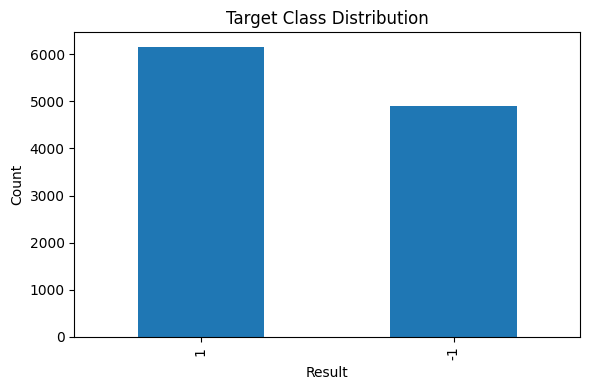

In [ ]:
plt.figure(figsize=(6,4))
df[target].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Result")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns=[target])
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (8844, 8), Test: (2211, 8)


In [ ]:
lr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

dt_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", DecisionTreeClassifier(random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", RandomForestClassifier(random_state=42))
])

gb_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [ ]:
def evaluate(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test, preds, average="weighted", zero_division=0)
    f1 = f1_score(y_test, preds, average="weighted", zero_division=0)

    print("=" * 40)
    print(f"Model     : {name}")
    print(f"Accuracy  : {acc:.3f}")
    print(f"Precision : {prec:.3f}")
    print(f"Recall    : {rec:.3f}")
    print(f"F1 Score  : {f1:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds, zero_division=0))

    return preds, acc, prec, rec, f1

In [ ]:
results = {}

models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

for name, pipe in models.items():
    preds, acc, prec, rec, f1 = evaluate(name, pipe, X_train, y_train, X_test, y_test)
    results[name] = {
        "pipeline": pipe,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

Model     : Logistic Regression
Accuracy  : 0.894
Precision : 0.896
Recall    : 0.894
F1 Score  : 0.894

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.84      0.88       980
           1       0.88      0.94      0.91      1231

    accuracy                           0.89      2211
   macro avg       0.90      0.89      0.89      2211
weighted avg       0.90      0.89      0.89      2211

Model     : Decision Tree
Accuracy  : 0.905
Precision : 0.905
Recall    : 0.905
F1 Score  : 0.904

Classification Report:
              precision    recall  f1-score   support

          -1       0.91      0.87      0.89       980
           1       0.90      0.93      0.92      1231

    accuracy                           0.90      2211
   macro avg       0.91      0.90      0.90      2211
weighted avg       0.90      0.90      0.90      2211

Model     : Random Forest
Accuracy  : 0.904
Precision : 0.904
Recall    : 0.904
F1 Score  : 0.90

In [ ]:
results_df = pd.DataFrame({
    name: {
        "Accuracy": info["accuracy"],
        "Precision": info["precision"],
        "Recall": info["recall"],
        "F1 Score": info["f1"]
    }
    for name, info in results.items()
}).T

results_df = results_df.sort_values("F1 Score", ascending=False)
results_df

,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.904568,0.904692,0.904568,0.904343
Random Forest,0.904116,0.904328,0.904116,0.903857
Gradient Boosting,0.899593,0.900502,0.899593,0.899121
Logistic Regression,0.894166,0.895579,0.894166,0.893542


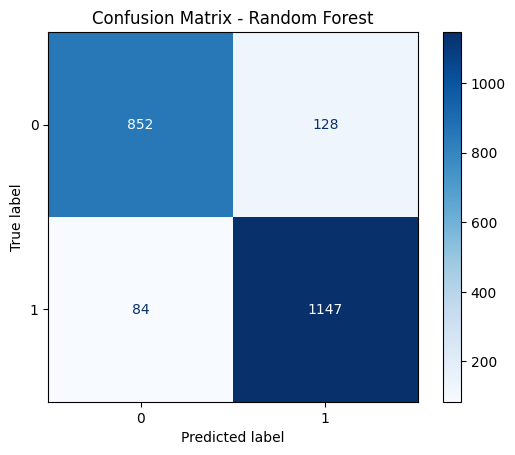

Chosen model for deployment: Random Forest
Model saved as best_phishing_model.pkl


In [ ]:
best_model_name = "Random Forest"
best_pipeline = results[best_model_name]["pipeline"]

best_pipeline.fit(X_train, y_train)
best_preds = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("Chosen model for deployment:", best_model_name)

joblib.dump(best_pipeline, "best_phishing_model.pkl")
print("Model saved as best_phishing_model.pkl")

In [ ]:
joblib.dump(best_pipeline, "best_phishing_model.pkl")
print("Model saved as best_phishing_model.pkl")

Model saved as best_phishing_model.pkl


In [ ]:
files.download("best_phishing_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
test_check = X_test.copy()
test_check["Actual_Result"] = y_test
test_check["Predicted_Result"] = best_pipeline.predict(X_test)
test_check.head(15)

,having_IP_Address,URL_Length,having_At_Symbol,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,age_of_domain,Redirect,Actual_Result,Predicted_Result
6461,-1,1,1,-1,0,0,1,0,-1,-1
10463,1,-1,1,-1,-1,1,1,0,-1,1
3390,1,1,1,1,1,1,1,0,1,1
4424,1,-1,1,-1,0,0,1,0,-1,-1
6256,1,0,1,-1,0,-1,-1,1,-1,-1
9808,-1,1,1,1,1,1,1,0,1,1
8396,1,-1,1,-1,1,1,1,0,1,1
9406,1,-1,1,1,1,1,1,0,1,1
10423,1,-1,1,-1,0,1,1,0,1,1
7787,1,-1,1,-1,1,-1,-1,0,-1,-1
